# Univariate Data Analysis and Data Quality Assessment

## Introduction

In this notebook, we perform a structured **univariate analysis** of both numerical and categorical variables within the Ames Housing dataset. Univariate analysis is a fundamental step in Exploratory Data Analysis (EDA), allowing us to understand the individual behavior of each feature before proceeding to multivariate analysis or predictive modeling.

---

### Topics Covered

- Examine distribution of numerical variables using descriptive statistics and visualizations
- Identify skewness and evaluate whether transformations are necessary
- Detect and interpret outliers using statistical criteria (IQR method)
- Analyze categorical variables through frequency tables and bar charts
- Identify rare levels and assess category imbalance
- Evaluate missing values and discuss appropriate handling strategies
- Assess and classify overall data quality of each attribute

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib
plt.style.use('default')
sns.set_palette('husl')

# Load processed dataset (without missing values)
df = pd.read_csv('../data/processed/AmesHousing_imputed.csv')
print(f'Dataset shape: {df.shape}')
print(f'Total missing values: {df.isna().sum().sum()}')

Dataset shape: (2930, 82)
Total missing values: 0


In [2]:
# Display first rows
df.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition,SalePrice
0,1.0,526301100.0,20.0,141.0,31770.0,6.0,5.0,1960.0,1960.0,112.0,...,Fin,TA,TA,P,Ex,MnPrv,Shed,WD,Normal,215000
1,2.0,526350040.0,20.0,80.0,11622.0,5.0,6.0,1961.0,1961.0,0.0,...,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal,105000
2,3.0,526351010.0,20.0,81.0,14267.0,6.0,6.0,1958.0,1958.0,108.0,...,Unf,TA,TA,Y,Ex,MnPrv,Gar2,WD,Normal,172000
3,4.0,526353030.0,20.0,93.0,11160.0,7.0,5.0,1968.0,1968.0,0.0,...,Fin,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal,244000
4,5.0,527105010.0,60.0,74.0,13830.0,5.0,5.0,1997.0,1998.0,0.0,...,Fin,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal,189900


## 2. Univariate Analysis of Numerical Variables

### 2.1 Descriptive Statistics

We begin by examining descriptive statistics for numerical variables. This provides a quantitative summary of central tendency, dispersion, and distribution shape.

In [3]:
# Select numerical columns (excluding identifiers)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove identifier columns
numerical_cols = [col for col in numerical_cols if col not in ['Order', 'PID']]

print(f'Number of numerical variables: {len(numerical_cols)}')
print(f'Numerical variables: {numerical_cols[:10]}...')  # Show first 10

Number of numerical variables: 37
Numerical variables: ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2']...


In [4]:
# Example: Analyze 'Lot Area' in detail
df['Lot Area'].describe()

count      2930.000000
mean      10147.921843
std        7880.017759
min        1300.000000
25%        7440.250000
50%        9436.500000
75%       11555.250000
max      215245.000000
Name: Lot Area, dtype: float64

### 2.2 Central Tendency and Dispersion

#### Key Metrics:
- **Mean vs Median**: If mean > median → positive skew (right tail); if mean < median → negative skew
- **Standard Deviation**: High values indicate greater variability
- **Range and IQR**: Large spread may indicate potential outliers

In [5]:
# Calculate additional metrics for Lot Area
lot_area_mean = df['Lot Area'].mean()
lot_area_median = df['Lot Area'].median()
lot_area_std = df['Lot Area'].std()
lot_area_cv = lot_area_std / lot_area_mean  # Coefficient of variation

print(f'Mean: {lot_area_mean:.2f}')
print(f'Median: {lot_area_median:.2f}')
print(f'Standard Deviation: {lot_area_std:.2f}')
print(f'Coefficient of Variation: {lot_area_cv:.4f}')

if lot_area_mean > lot_area_median:
    print('\nThe distribution of Lot Area is positively skewed (right tail).')
elif lot_area_mean < lot_area_median:
    print('\nThe distribution of Lot Area is negatively skewed (left tail).')
else:
    print('\nThe distribution of Lot Area is approximately symmetric.')

Mean: 10147.92
Median: 9436.50
Standard Deviation: 7880.02
Coefficient of Variation: 0.7765

The distribution of Lot Area is positively skewed (right tail).


### 2.3 Range and Interquartile Range (IQR)

The **Interquartile Range (IQR)** represents the spread of the middle 50% of the data:

$$IQR = Q_3 - Q_1$$

Unlike the range (max − min), the IQR is a **robust measure of variability** that focuses on the central portion of the data.

In [6]:
# Calculate range and IQR
lot_area_range = df['Lot Area'].max() - df['Lot Area'].min()
lot_area_q1 = df['Lot Area'].quantile(0.25)
lot_area_q3 = df['Lot Area'].quantile(0.75)
lot_area_iqr = lot_area_q3 - lot_area_q1

print(f'Range of Lot Area: {lot_area_range:.2f}')
print(f'Q1 (25th percentile): {lot_area_q1:.2f}')
print(f'Q3 (75th percentile): {lot_area_q3:.2f}')
print(f'IQR (Interquartile Range): {lot_area_iqr:.2f}')

if lot_area_range > 3 * lot_area_iqr:
    print('\nThe range is significantly larger than the IQR, suggesting potential outliers.')

Range of Lot Area: 213945.00
Q1 (25th percentile): 7440.25
Q3 (75th percentile): 11555.25
IQR (Interquartile Range): 4115.00

The range is significantly larger than the IQR, suggesting potential outliers.


### 2.4 Outlier Detection Using IQR Method

The IQR method defines outliers as observations falling outside:

- **Lower Bound**: $Q_1 - 1.5 \times IQR$
- **Upper Bound**: $Q_3 + 1.5 \times IQR$

In [7]:
# Detect outliers using IQR method
lower_bound = lot_area_q1 - 1.5 * lot_area_iqr
upper_bound = lot_area_q3 + 1.5 * lot_area_iqr

outliers = df[(df['Lot Area'] < lower_bound) | (df['Lot Area'] > upper_bound)]

print(f'Lower Bound: {lower_bound:.2f}')
print(f'Upper Bound: {upper_bound:.2f}')
print(f'Number of outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)')
print(f'\nTop 5 outliers (largest Lot Area):')
print(outliers[['Lot Area', 'Neighborhood', 'SalePrice']].nlargest(5, 'Lot Area'))

Lower Bound: 1267.75
Upper Bound: 17727.75
Number of outliers detected: 127 (4.33% of data)

Top 5 outliers (largest Lot Area):
      Lot Area Neighborhood  SalePrice
956   215245.0       Timber     375000
1570  164660.0       Timber     228950
2115  159000.0      ClearCr     277000
2071  115149.0      ClearCr     302000
2766   70761.0      ClearCr     280000


### 2.5 Boxplot Visualization

A boxplot provides a visual summary of the distribution, highlighting the median, quartiles, and potential outliers.

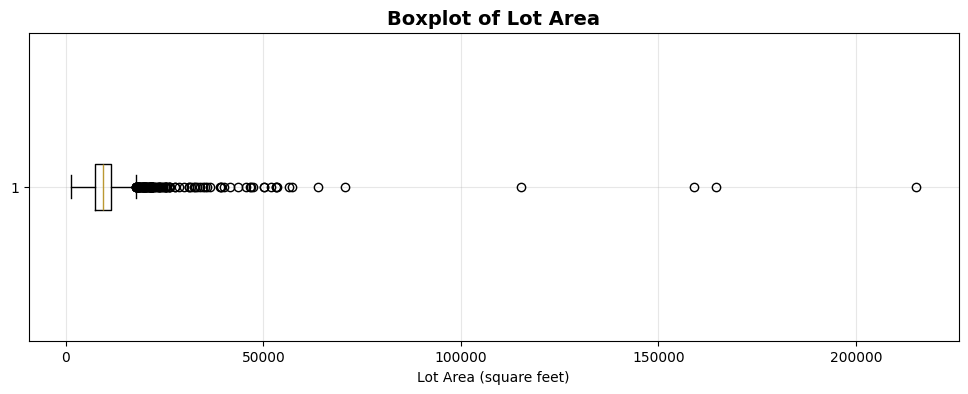

In [8]:
# Boxplot of Lot Area
plt.figure(figsize=(12, 4))
plt.boxplot(df['Lot Area'], vert=False)
plt.title('Boxplot of Lot Area', fontsize=14, fontweight='bold')
plt.xlabel('Lot Area (square feet)')
plt.grid(alpha=0.3)
plt.show()

### 2.6 Skewness Analysis

**Skewness** measures the degree of asymmetry of a distribution around its mean:

- Skewness = 0 → perfectly symmetric distribution
- Skewness > 0 → right-skewed (long right tail)
- Skewness < 0 → left-skewed (long left tail)

#### Interpretation Guidelines:
- |Skewness| < 0.5 → Approximately symmetric
- 0.5 ≤ |Skewness| < 1 → Moderately skewed
- |Skewness| ≥ 1 → Highly skewed

In [9]:
# Calculate skewness
lot_area_skew = df['Lot Area'].skew()
print(f'Skewness of Lot Area: {lot_area_skew:.4f}')

if abs(lot_area_skew) < 0.5:
    skew_interpretation = 'approximately symmetric'
elif abs(lot_area_skew) < 1:
    skew_interpretation = 'moderately skewed'
else:
    skew_interpretation = 'highly skewed'

direction = 'right' if lot_area_skew > 0 else 'left'
print(f'Interpretation: The distribution is {skew_interpretation} to the {direction}.')

Skewness of Lot Area: 12.8209
Interpretation: The distribution is highly skewed to the right.


### 2.7 Histogram Visualization

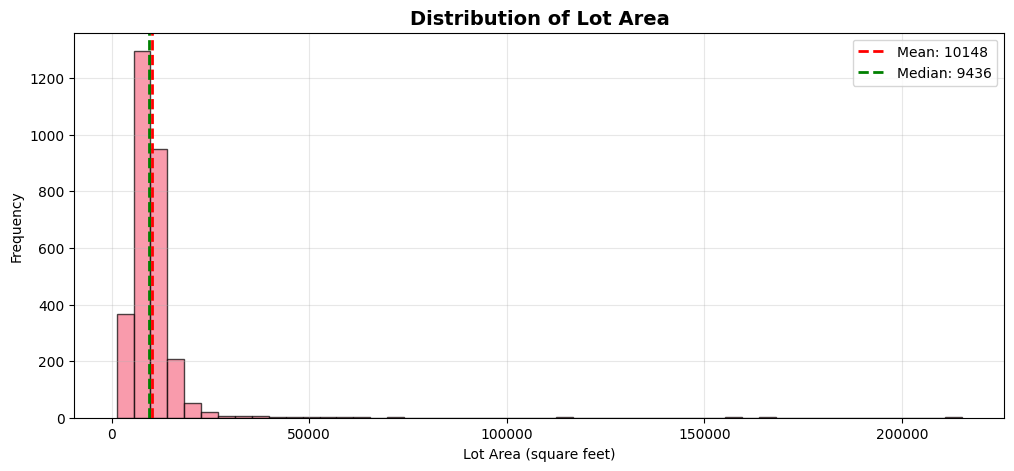

In [10]:
# Histogram of Lot Area
plt.figure(figsize=(12, 5))
plt.hist(df['Lot Area'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(lot_area_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {lot_area_mean:.0f}')
plt.axvline(lot_area_median, color='green', linestyle='--', linewidth=2, label=f'Median: {lot_area_median:.0f}')
plt.title('Distribution of Lot Area', fontsize=14, fontweight='bold')
plt.xlabel('Lot Area (square feet)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2.8 Kurtosis Analysis

**Kurtosis** measures the heaviness of the tails and the concentration of extreme values:

- Kurtosis = 0 → Normal distribution
- Kurtosis > 0 → Heavy tails (leptokurtic) - more extreme values
- Kurtosis < 0 → Light tails (platykurtic)

#### Interpretation Guidelines:
- Kurtosis ≈ 0 → Similar to normal distribution
- 0 < Kurtosis < 3 → Moderately heavy tails
- Kurtosis ≥ 3 → Heavy tails with extreme values

In [11]:
# Calculate kurtosis
lot_area_kurt = df['Lot Area'].kurt()
print(f'Kurtosis of Lot Area: {lot_area_kurt:.4f}')

if abs(lot_area_kurt) < 0.5:
    kurt_interpretation = 'similar to normal distribution'
elif lot_area_kurt >= 3:
    kurt_interpretation = 'heavy tails with extreme values (strongly leptokurtic)'
elif lot_area_kurt > 0:
    kurt_interpretation = 'moderately heavy tails (leptokurtic)'
else:
    kurt_interpretation = 'light tails (platykurtic)'

print(f'Interpretation: The distribution has {kurt_interpretation}.')
print(f'\nThis indicates that the distribution has {"more" if lot_area_kurt > 0 else "fewer"} extreme values than a normal distribution.')

Kurtosis of Lot Area: 265.0237
Interpretation: The distribution has heavy tails with extreme values (strongly leptokurtic).

This indicates that the distribution has more extreme values than a normal distribution.


### 2.9 Data Quality Assessment for Numerical Variables

Based on the analysis above, we can assess the data quality of the numerical variable:

In [ ]:
# Summary assessment
print('='*60)
print('DATA QUALITY ASSESSMENT: Lot Area')
print('='*60)
print(f'\n✓ Completeness: {df["Lot Area"].notna().sum()} / {len(df)} observations ({df["Lot Area"].notna().sum()/len(df)*100:.2f}%)')

# Variability classification
if lot_area_cv > 0.5:
    variability_level = "High"
elif lot_area_cv > 0.2:
    variability_level = "Moderate"
else:
    variability_level = "Low"

print(f'✓ Variability: CV = {lot_area_cv:.4f} ({variability_level} variability)')
print(f'✓ Symmetry: Skewness = {lot_area_skew:.4f} ({skew_interpretation})')
print(f'✓ Tail Behavior: Kurtosis = {lot_area_kurt:.4f} ({kurt_interpretation})')
print(f'✓ Outliers: {len(outliers)} observations ({len(outliers)/len(df)*100:.2f}%)')

print(f'\n{'='*60}')
print('OVERALL ASSESSMENT:')
print(f'{'='*60}')
print('From a DATA VALIDITY perspective: The variable is reliable and meaningful.')
print('From a STATISTICAL MODELING perspective: The variable presents challenges:')
print('  - High dispersion and variability')
print(f'  - Strong {direction}-skewness')
print('  - Heavy tails with extreme values')
print('\nRECOMMENDATION: Consider log transformation or robust scaling methods.')
print(f'{'='*60}')

SyntaxError: f-string: expecting a valid expression after '{' (4010411563.py, line 7)

### 2.10 Comprehensive Analysis for All Numerical Variables

In [ ]:
# Create summary statistics for all numerical variables
numeric_summary = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std': df[numerical_cols].std(),
    'CV': df[numerical_cols].std() / df[numerical_cols].mean(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurt(),
    'Missing%': df[numerical_cols].isna().sum() / len(df) * 100
})

# Sort by absolute skewness to identify most skewed variables
numeric_summary['Abs_Skewness'] = numeric_summary['Skewness'].abs()
numeric_summary_sorted = numeric_summary.sort_values('Abs_Skewness', ascending=False)

print('Top 10 Most Skewed Numerical Variables:')
numeric_summary_sorted[['Mean', 'Median', 'Skewness', 'Kurtosis']].head(10)

## 3. Univariate Analysis of Categorical Variables

### 3.1 Overview

Categorical features can present specific challenges:
- Imbalanced categories
- Rare levels
- High cardinality
- Inconsistent or noisy labels

In [ ]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f'Number of categorical variables: {len(categorical_cols)}')
print(f'Categorical variables: {categorical_cols}')

### 3.2 Example: MS Zoning Analysis

Let's perform a detailed analysis of the 'MS Zoning' variable.

In [ ]:
# Value counts for MS Zoning
ms_zoning_counts = df['MS Zoning'].value_counts()
ms_zoning_pct = df['MS Zoning'].value_counts(normalize=True) * 100

print('MS Zoning - Absolute Frequencies:')
print(ms_zoning_counts)
print('\nMS Zoning - Relative Frequencies (%):')
print(ms_zoning_pct.round(2))

### 3.3 Cardinality Assessment

In [ ]:
# Evaluate cardinality
cardinality = df['MS Zoning'].nunique()
print(f'Cardinality of MS Zoning: {cardinality}')

if cardinality > 20:
    print('⚠️  High cardinality variable - may require encoding strategy adjustment')
elif cardinality > 10:
    print('⚠️  Moderate cardinality - monitor for rare categories')
else:
    print('✓ Low to moderate cardinality - suitable for standard encoding')

### 3.4 Identifying Rare Categories

Categories with very few observations may cause issues in modeling.

In [ ]:
# Define rare threshold (e.g., < 5% of data)
rare_threshold = 0.05

rare_categories = df['MS Zoning'].value_counts(normalize=True) < rare_threshold
rare_category_counts = df['MS Zoning'].value_counts()[rare_categories]

print(f'Rare categories (< {rare_threshold*100}% of data):')
print(rare_category_counts)
print(f'\nNumber of rare categories: {rare_categories.sum()}')

if rare_categories.sum() > 0:
    print('\n⚠️  Consider grouping rare categories or handling them separately in modeling')

### 3.5 Bar Chart Visualization

In [ ]:
# Bar chart for MS Zoning
plt.figure(figsize=(12, 5))
ms_zoning_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of MS Zoning', fontsize=14, fontweight='bold')
plt.xlabel('MS Zoning Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Comprehensive Analysis for All Categorical Variables

In [ ]:
# Create summary for all categorical variables
categorical_summary = pd.DataFrame({
    'Cardinality': [df[col].nunique() for col in categorical_cols],
    'Most_Frequent': [df[col].value_counts().index[0] if len(df[col].dropna()) > 0 else None for col in categorical_cols],
    'Most_Freq_Count': [df[col].value_counts().iloc[0] if len(df[col].dropna()) > 0 else 0 for col in categorical_cols],
    'Most_Freq_Pct': [df[col].value_counts(normalize=True).iloc[0] * 100 if len(df[col].dropna()) > 0 else 0 for col in categorical_cols],
    'Missing%': [df[col].isna().sum() / len(df) * 100 for col in categorical_cols],
    'Rare_Categories': [(df[col].value_counts(normalize=True) < rare_threshold).sum() for col in categorical_cols]
}, index=categorical_cols)

# Sort by cardinality
categorical_summary_sorted = categorical_summary.sort_values('Cardinality', ascending=False)

print('Categorical Variables Summary:')
categorical_summary_sorted

## 4. Overall Data Quality Report

In [ ]:
# Generate comprehensive quality report
print('='*80)
print('COMPREHENSIVE DATA QUALITY REPORT - AMES HOUSING DATASET')
print('='*80)

print(f'\nDataset Shape: {df.shape[0]} observations × {df.shape[1]} features')
print(f'\nNumerical Variables: {len(numerical_cols)}')
print(f'Categorical Variables: {len(categorical_cols)}')

print('\n' + '='*80)
print('NUMERICAL VARIABLES - KEY FINDINGS:')
print('='*80)
highly_skewed = numeric_summary[abs(numeric_summary['Skewness']) > 1]
print(f'\n✓ Highly skewed variables (|skewness| > 1): {len(highly_skewed)}')
print(f'  Top 5: {highly_skewed.index[:5].tolist()}')

high_kurtosis = numeric_summary[numeric_summary['Kurtosis'] > 3]
print(f'\n✓ Variables with heavy tails (kurtosis > 3): {len(high_kurtosis)}')
print(f'  Top 5: {high_kurtosis.index[:5].tolist()}')

with_missing = numeric_summary[numeric_summary['Missing%'] > 0]
print(f'\n✓ Variables with missing values: {len(with_missing)}')
if len(with_missing) > 0:
    print(f'  Top 5 by missing%: {with_missing.sort_values("Missing%", ascending=False).index[:5].tolist()}')

print('\n' + '='*80)
print('CATEGORICAL VARIABLES - KEY FINDINGS:')
print('='*80)

high_cardinality = categorical_summary[categorical_summary['Cardinality'] > 10]
print(f'\n✓ High cardinality variables (>10 categories): {len(high_cardinality)}')
if len(high_cardinality) > 0:
    print(f'  Variables: {high_cardinality.index.tolist()}')

with_rare = categorical_summary[categorical_summary['Rare_Categories'] > 0]
print(f'\n✓ Variables with rare categories (<{rare_threshold*100}%): {len(with_rare)}')
if len(with_rare) > 0:
    print(f'  Top 5: {with_rare.sort_values("Rare_Categories", ascending=False).index[:5].tolist()}')

cat_with_missing = categorical_summary[categorical_summary['Missing%'] > 0]
print(f'\n✓ Categorical variables with missing values: {len(cat_with_missing)}')
if len(cat_with_missing) > 0:
    print(f'  Top 5 by missing%: {cat_with_missing.sort_values("Missing%", ascending=False).index[:5].tolist()}')

print('\n' + '='*80)
print('RECOMMENDATIONS:')
print('='*80)
print('\n1. TRANSFORMATIONS:')
print('   - Apply log transformation to highly skewed numerical variables')
print('   - Consider Box-Cox transformation for variables with extreme kurtosis')
print('\n2. CATEGORICAL ENCODING:')
print('   - Group rare categories for stability')
print('   - Use target encoding for high-cardinality variables')
print('   - Consider frequency encoding for imbalanced categories')
print('\n3. MISSING VALUES:')
print('   - Already handled in missing_values_pipeline.ipynb')
print('   - Verify imputation quality before modeling')
print('\n4. OUTLIERS:')
print('   - Investigate domain context of outliers before removal')
print('   - Consider robust scaling methods for modeling')
print('='*80)

## 5. Export Quality Summary

In [ ]:
# Export numeric summary
numeric_summary.to_csv('../reports/numeric_quality_summary.csv')
categorical_summary.to_csv('../reports/categorical_quality_summary.csv')

print('✓ Quality summaries exported to ../reports/')
print('  - numeric_quality_summary.csv')
print('  - categorical_quality_summary.csv')